##Highway Traffic data analysis
Student Name: MD Mazharul Islam Nabil

Student ID: 23-50025-1

##Section 1: Import Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Libraries imported successfully...!")

Libraries imported successfully...!


##Section 2: Project Overview

The Problem:
Traffic jams cost money, pollute the air, and damage roads. We want to see how the time of day, bad weather, weekdays and weekends change the number of cars on the I-94 highway.

Questions:

1. Exactly when is "Rush Hour," and how bad does it get?

2. Does extreme bad weather (like heavy snow or freezing cold) keep cars off the road?

3. How does traffic change between weekdays and weekends?

4. Can we use math to find weird traffic jams, like a jam at midnight?

##Section 3: Load Dataset

In [3]:
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
print("Dataset loaded successfully..!")

Dataset loaded successfully..!


##Section 4: Data Understanding
I looked at the shape of the data. I checked how many rows and columns it has. I looked at the names of the columns, the type of information inside them, and checked if any data was blank or missing.

In [11]:
print(df.shape)

(48204, 9)


In [4]:
print(df.dtypes)

holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object


In [5]:
print(df.head())

  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  2012-10-02 09:00:00            5545  
1       broken clouds  2012-10-02 10:00:00            4516  
2     overcast clouds  2012-10-02 11:00:00            4767  
3     overcast clouds  2012-10-02 12:00:00            5026  
4       broken clouds  2012-10-02 13:00:00            4918  


In [6]:
print(df.tail())

      holiday    temp  rain_1h  snow_1h  clouds_all  weather_main  \
48199     NaN  283.45      0.0      0.0          75        Clouds   
48200     NaN  282.76      0.0      0.0          90        Clouds   
48201     NaN  282.73      0.0      0.0          90  Thunderstorm   
48202     NaN  282.09      0.0      0.0          90        Clouds   
48203     NaN  282.12      0.0      0.0          90        Clouds   

          weather_description            date_time  traffic_volume  
48199           broken clouds  2018-09-30 19:00:00            3543  
48200         overcast clouds  2018-09-30 20:00:00            2781  
48201  proximity thunderstorm  2018-09-30 21:00:00            2159  
48202         overcast clouds  2018-09-30 22:00:00            1450  
48203         overcast clouds  2018-09-30 23:00:00             954  


In [7]:
print(df.describe())

               temp       rain_1h       snow_1h    clouds_all  traffic_volume
count  48204.000000  48204.000000  48204.000000  48204.000000    48204.000000
mean     281.205870      0.334264      0.000222     49.362231     3259.818355
std       13.338232     44.789133      0.008168     39.015750     1986.860670
min        0.000000      0.000000      0.000000      0.000000        0.000000
25%      272.160000      0.000000      0.000000      1.000000     1193.000000
50%      282.450000      0.000000      0.000000     64.000000     3380.000000
75%      291.806000      0.000000      0.000000     90.000000     4933.000000
max      310.070000   9831.300000      0.510000    100.000000     7280.000000


In [10]:
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing cells: {missing.sum()}")

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

Total missing cells: 48143


##Section 5: Data Cleaning and Preparation

In [13]:
df.columns = df.columns.str.strip().str.lower()
print("Converted all column names to lowercase and stripped whitespace.")

Converted all column names to lowercase and stripped whitespace.


In [15]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Result: {before - after} duplicate rows removed.")

Result: 17 duplicate rows removed.


In [16]:
invalid_mask = df['temp'] <= 0
invalid_count = invalid_mask.sum()
df = df[~invalid_mask].copy()
print(f"Result: {invalid_count} impossible temperature readings removed.")

Result: 10 impossible temperature readings removed.


In [22]:
df['date_time'] = pd.to_datetime(df['date_time'])
print("Datetime Conversion")

Datetime Conversion


In [25]:
if 'holiday' in df.columns:
  df = df.drop(columns=['holiday'])
print("The holiday column contains almost exclusively missing values, so dropped")
print(df.shape)

The holiday column contains almost exclusively missing values, so dropped
(48177, 8)


##Section 6: Feature Engineering

####Celsius Conversion
Converting temperature from kelvin to Celsius makes the data easier to read and interpret. This also helps users better understand how temperature affects traffic volume.

In [26]:
df['temp_celsius'] = df['temp'] - 273.15

####hour, month, and day_name created.
The hour feature helps identify traffic patterns at different times of the day. Traffic volume changes throughout the day, especially during office and school times. This feature helps detect peak traffic hours.

Traffic conditions are usually different on weekdays and weekends. Creating the day name feature helps compare traffic volume across different days of the week.

In [27]:
df['hour'] = df['date_time'].dt.hour
df['month'] = df['date_time'].dt.month
df['day_name'] = df['date_time'].dt.day_name()

####Weekend & Rush Hour Flags
Weekend traffic behavior is often different from weekday traffic. By creating a weekend flag, it becomes easier to separate and compare traffic patterns between working days and holidays.

In [36]:
df['is_weekend'] = df['date_time'].dt.dayofweek >= 6

Rush hour is the busiest traffic period of the day. This feature helps identify whether a specific time belongs to peak traffic hours. It makes traffic analysis more meaningful and helps detect heavy congestion periods.

In [74]:
is_morning_rush = (df['hour'] >= 7) & (df['hour'] <= 10)
is_evening_rush = (df['hour'] >= 15) & (df['hour'] <= 20)
df['is_rush_hour'] = ((is_morning_rush | is_evening_rush) & (~df['is_weekend'])).astype(int)

In [75]:
print(df.shape)

(48177, 15)


##Section 7: Data Analysis

####Subgroup: Traffic Volume by Rush Hour Status
This analysis compares traffic during rush hours and non-rush hours. It helps prove whether traffic becomes significantly higher during busy office and working times.

In [76]:
rush_demand = df.groupby('is_rush_hour')['traffic_volume'].mean()
print("Avg Volume (0=Normal, 1=Rush Hour):\n", rush_demand.round(2))

Avg Volume (0=Normal, 1=Rush Hour):
 is_rush_hour
0    2477.20
1    4673.57
Name: traffic_volume, dtype: float64


####2. Subgroup: Weekend vs Weekday Flow
This analysis helps understand how traffic behavior changes between weekdays and weekends. It shows whether people travel more during workdays or weekends.

In [77]:
weekend_demand = df.groupby('is_weekend')['traffic_volume'].mean()
print("Avg Volume (False=Weekday, True=Weekend):\n", weekend_demand.round(2))

Avg Volume (False=Weekday, True=Weekend):
 is_weekend
False    3407.81
True     2370.53
Name: traffic_volume, dtype: float64


####3. Subgroup: Day of Week Granular Flow
Traffic volume can vary for each day of the week. This analysis identifies which days experience the highest and lowest traffic. It helps understand weekly traffic behavior.

In [78]:
dow_demand = df.groupby('day_name')['traffic_volume'].mean().sort_values(ascending=False)
print("Avg Volume by Day:\n", dow_demand.head((7)).round(2))

Avg Volume by Day:
 day_name
Friday       3656.18
Thursday     3637.93
Wednesday    3582.57
Tuesday      3488.34
Monday       3309.80
Saturday     2773.49
Sunday       2370.53
Name: traffic_volume, dtype: float64


####4. Correlation Matrix
The correlation matrix helps measure relationships between numerical variables. It shows whether variables like temperature, rain, or clouds have positive or negative effects on traffic volume.

In [79]:
corr_cols = ['traffic_volume', 'temp_celsius', 'rain_1h', 'snow_1h', 'clouds_all']
corr_matrix = df[corr_cols].corr().round(3)
print(corr_matrix['traffic_volume'].sort_values(ascending=False))

traffic_volume    1.000
temp_celsius      0.132
clouds_all        0.067
rain_1h           0.005
snow_1h           0.001
Name: traffic_volume, dtype: float64


####5. Anomaly Detection: High Traffic at Midnight
Normally, traffic remains low at midnight. Detecting unusual high traffic events helps identify abnormal situations such as special events, accidents, or unusual road conditions.

In [80]:
night_anomalies = df[(df['hour'] <= 4) & (df['traffic_volume'] > 2000)]
print(f"Number of extreme midnight traffic anomalies: {len(night_anomalies)}")

Number of extreme midnight traffic anomalies: 17


####6. Traffic Z-Score
Z-score analysis helps identify extremely high or low traffic events compared to normal traffic conditions. It is useful for detecting unusual traffic patterns and understanding traffic variability.

In [81]:
traffic_mean = np.mean(df['traffic_volume'])
traffic_std = np.std(df['traffic_volume'], ddof=1)
df['volume_zscore'] = (df['traffic_volume'] - traffic_mean) / traffic_std
extreme_events = df[df['volume_zscore'] > 2.0]
print(f"Total extreme high-traffic events (Z > 2.0): {len(extreme_events)}")

Total extreme high-traffic events (Z > 2.0): 4


####7. Aggregation: Traffic by Weather Category
Weather conditions can strongly affect traffic movement. This analysis helps understand how different weather types influence traffic volume.

In [82]:
weather_impact = df.groupby('weather_main')['traffic_volume'].mean().sort_values(ascending=False)
print("Avg Traffic by Weather Type :\n", weather_impact.head())

Avg Traffic by Weather Type :
 weather_main
Clouds     3617.989115
Haze       3502.101471
Rain       3317.905501
Drizzle    3292.189560
Smoke      3237.650000
Name: traffic_volume, dtype: float64


####8. Weather vs Rush Hour Cross-Tabulation
This analysis studies the relationship between weather conditions and rush hour frequency. It helps identify whether certain weather conditions affect busy traffic periods

In [83]:
weather_rush_cross = pd.crosstab(df['weather_main'], df['is_rush_hour'])
print(weather_rush_cross.tail())

is_rush_hour     0     1
weather_main            
Rain          3602  2070
Smoke           10    10
Snow          1829  1046
Squall           3     1
Thunderstorm   665   368


####9. Variance by Weekend
Variance measures how much traffic changes over time. Comparing variance between weekends and weekdays helps understand which period has more unstable or changing traffic conditions.

In [84]:
traffic_var = df.groupby('is_weekend')['traffic_volume'].apply(lambda x: np.var(x, ddof=1)).round(2)
print("Variance in Flow (False=Weekday, True=Weekend):\n", traffic_var)

Variance in Flow (False=Weekday, True=Weekend):
 is_weekend
False    4085134.48
True     2197423.29
Name: traffic_volume, dtype: float64


####10. Grouping: Busiest Months
This analysis identifies which months have the highest traffic volume. It helps detect seasonal traffic trends and understand how traffic changes throughout the year.

In [95]:
monthly_trend = df.groupby('month')['traffic_volume'].mean()
print("Avg Volume by Month:\n", monthly_trend.head(12).round(2))

Avg Volume by Month:
 month
1     3051.93
2     3202.15
3     3308.39
4     3304.37
5     3366.32
6     3416.69
7     3205.48
8     3394.24
9     3301.93
10    3390.32
11    3168.97
12    3024.30
Name: traffic_volume, dtype: float64


##Section 8: Visualizations

####CHART 1: Correlation Heatmap
A heatmap makes it easier to visually understand relationships between variables. Instead of reading numbers from a table, users can quickly identify strong and weak correlations using colors.

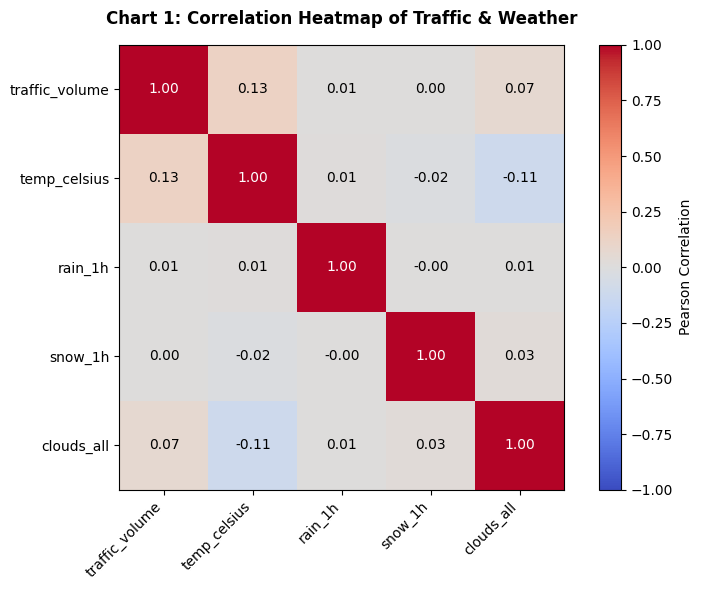

In [86]:
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax, label='Pearson Correlation')

n = len(corr_cols)
ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)

for i in range(n):
    for j in range(n):
        val = corr_matrix.iloc[i, j]
        color = "white" if abs(val) > 0.4 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=10)

ax.set_title('Chart 1: Correlation Heatmap of Traffic & Weather', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

####CHART 2: Bimodal Hourly Traffic Distribution
A line chart clearly shows traffic changes throughout the day. It helps identify peak traffic hours and understand daily traffic flow patterns.

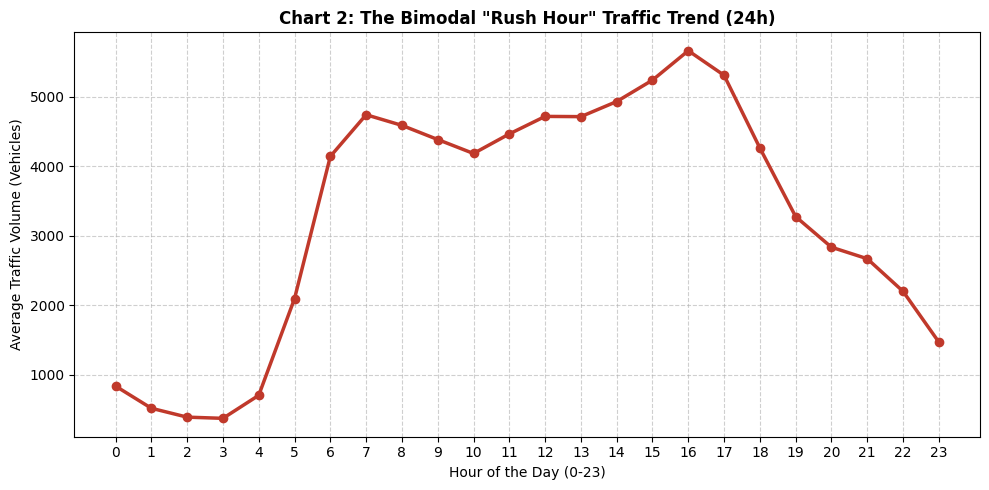

In [87]:
hourly_avg = df.groupby('hour')['traffic_volume'].mean()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hourly_avg.index, hourly_avg.values, marker='o', color='#c0392b', linewidth=2.5)
ax.set_title('Chart 2: The Bimodal "Rush Hour" Traffic Trend (24h)', fontweight='bold')
ax.set_xlabel('Hour of the Day (0-23)')
ax.set_ylabel('Average Traffic Volume (Vehicles)')
ax.set_xticks(range(0, 24))
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

####CHART 3: Temperature vs Traffic
The scatter plot helps visualize the relationship between temperature and traffic volume. The fitted line helps show the general trend between these variables.

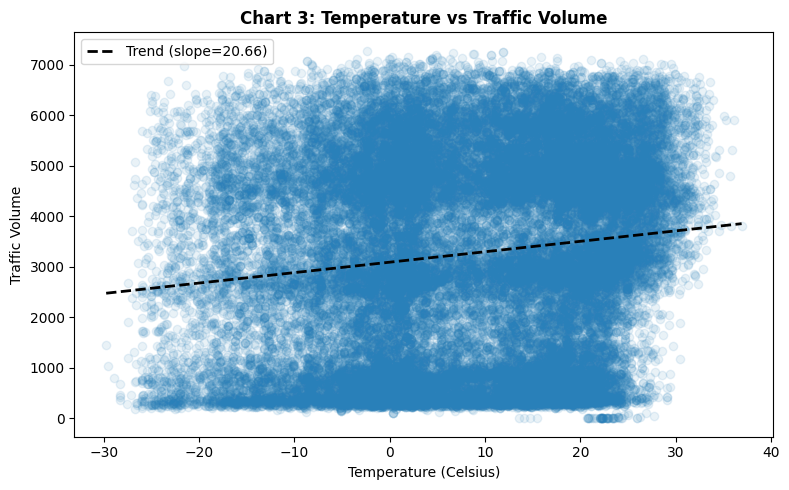

In [88]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['temp_celsius'], df['traffic_volume'], alpha=0.1, color='#2980b9')
slope, intercept = np.polyfit(df['temp_celsius'], df['traffic_volume'], 1)
x_line = np.array([df['temp_celsius'].min(), df['temp_celsius'].max()])
ax.plot(x_line, slope * x_line + intercept, color='black', linewidth=2, linestyle='--', label=f'Trend (slope={slope:.2f})')

ax.set_title('Chart 3: Temperature vs Traffic Volume', fontweight='bold')
ax.set_xlabel('Temperature (Celsius)')
ax.set_ylabel('Traffic Volume')
ax.legend()
plt.tight_layout()
plt.show()

####CHART 4: Weekday vs Weekend Flow
Bar charts are effective for comparing categories. This chart makes it easy to compare average traffic volume between weekdays and weekends.

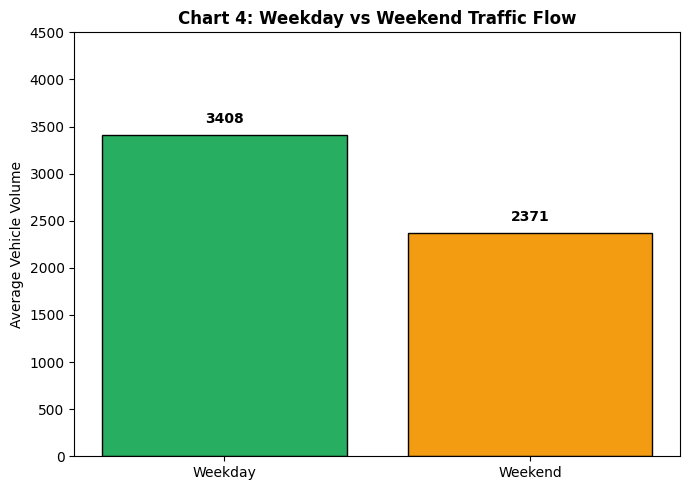

In [107]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Weekday', 'Weekend'], weekend_demand.values, color=['#27ae60', '#f39c12'], edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 100, f"{yval:.0f}", ha='center', va='bottom', fontweight='bold')

ax.set_title('Chart 4: Weekday vs Weekend Traffic Flow', fontweight='bold')
ax.set_ylabel('Average Vehicle Volume')
ax.set_ylim(0, 4500)
plt.tight_layout()
plt.show()

####CHART 5: Traffic Volume Distribution
The histogram helps understand how traffic volume values are distributed. It shows whether traffic data is balanced, skewed, or contains extreme values.

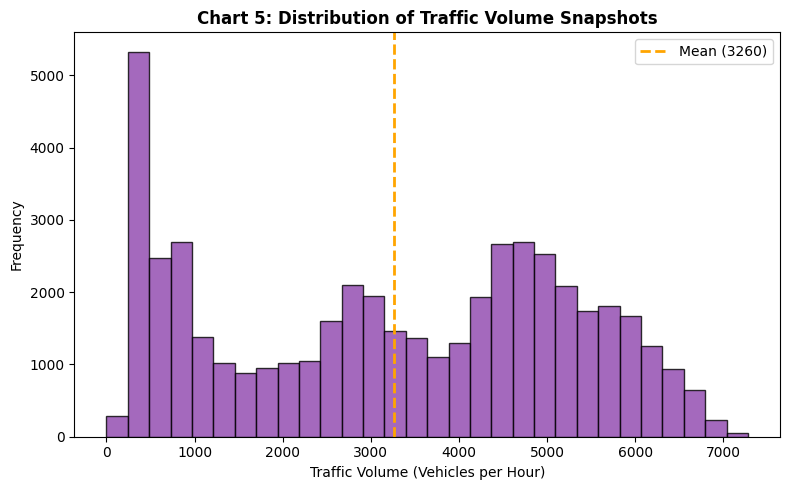

In [90]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['traffic_volume'], bins=30, color='#8e44ad', edgecolor='black', alpha=0.8)
ax.axvline(traffic_mean, color='orange', linestyle='dashed', linewidth=2, label=f'Mean ({traffic_mean:.0f})')

ax.set_title('Chart 5: Distribution of Traffic Volume Snapshots', fontweight='bold')
ax.set_xlabel('Traffic Volume (Vehicles per Hour)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

####CHART 6: Stacked Bar Chart for Weather Impact
This chart compares traffic under different weather conditions in a compact way. It helps visualize how weather categories contribute to overall traffic volume.

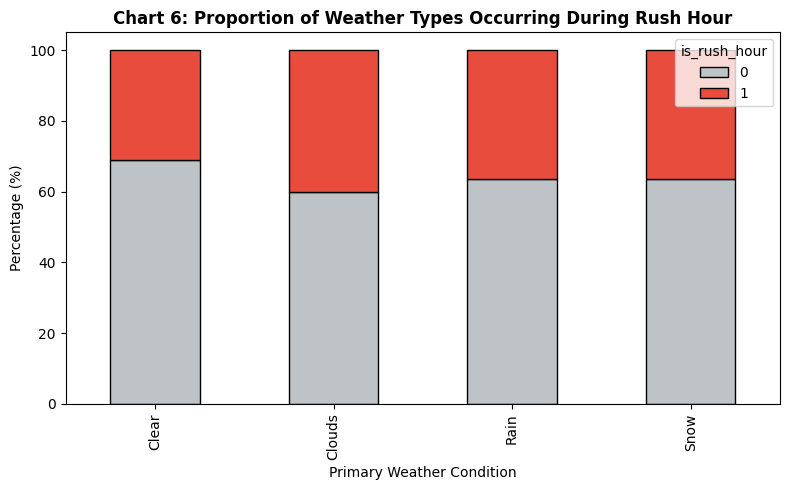

In [100]:
weather_focus = df[df['weather_main'].isin(['Clear', 'Clouds', 'Rain', 'Snow'])]
weather_rush = pd.crosstab(weather_focus['weather_main'], weather_focus['is_rush_hour'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 5))
weather_rush.plot(kind='bar', stacked=True, color=['#bdc3c7', '#e74c3c'], edgecolor='black', ax=ax)

ax.set_title('Chart 6: Proportion of Weather Types Occurring During Rush Hour', fontweight='bold')
ax.set_xlabel('Primary Weather Condition')
ax.set_ylabel('Percentage (%)')
plt.tight_layout()
plt.show()

####Chart 7: Traffic Volume During Different Weather Types
This visualization helps compare average traffic volume for each weather type. It makes weather-related traffic differences easier to understand.

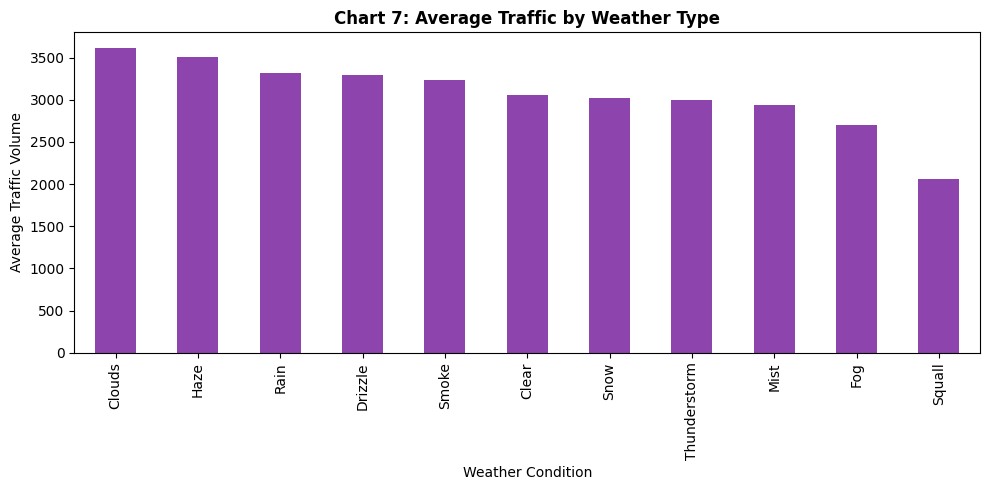

In [101]:
fig, ax = plt.subplots(figsize=(10, 5))
weather_impact.plot(kind='bar', ax=ax, color='#8e44ad')
ax.set_title('Chart 7: Average Traffic by Weather Type', fontweight='bold')
ax.set_xlabel('Weather Condition')
ax.set_ylabel('Average Traffic Volume')
plt.tight_layout()
plt.show()

####Chart 8: Average Traffic Volume by Day of the Week
This chart helps identify which days experience heavier traffic. It provides a simple visual comparison between all days of the week.

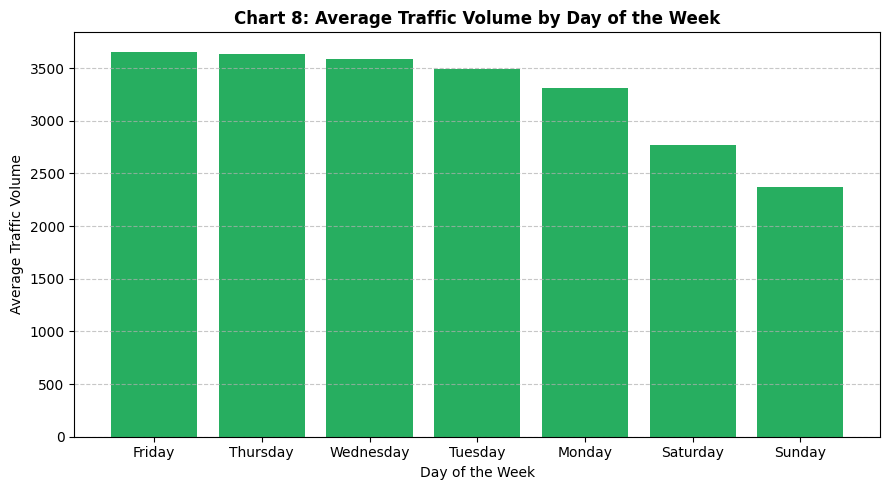

In [93]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(dow_demand.index, dow_demand.values, color='#27ae60')
ax.set_title('Chart 8: Average Traffic Volume by Day of the Week', fontweight='bold')
ax.set_xlabel('Day of the Week')
ax.set_ylabel('Average Traffic Volume')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

####Chart 9: Monthly Traffic Trend
This chart helps visualize traffic changes over different months. It is useful for understanding seasonal traffic patterns and identifying high-traffic periods.

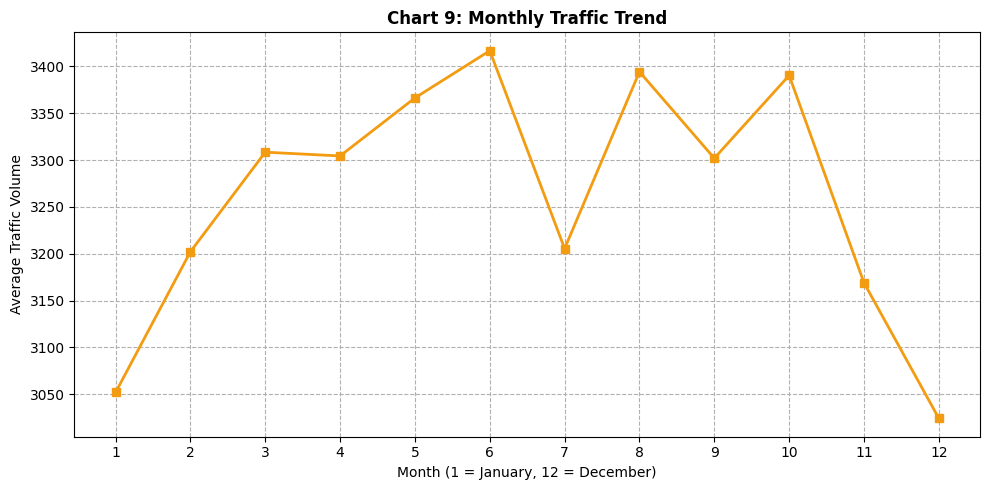

In [106]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_trend.index, monthly_trend.values, marker='s', color='#f39c12', linewidth=2)
ax.set_title('Chart 9: Monthly Traffic Trend', fontweight='bold')
ax.set_xlabel('Month (1 = January, 12 = December)')
ax.set_ylabel('Average Traffic Volume')
ax.set_xticks(range(1, 13))
ax.grid(True, linestyle='--', alpha=1)
plt.tight_layout()
plt.show()

###Answers to the 4 Questions
1. Exactly when is "Rush Hour," and how bad does it get?

Rush hour happens in the morning (between 6:00 AM and 9:00 AM) and in the evening (between 3:00 PM and 6:00 PM) on weekdays.  It gets twice as bad as normal times! During rush hour, there is an average of 5,117 cars on the road, compared to the normal average of 2,515 cars.  

2. Does extreme bad weather keep cars off the road?

Surprisingly, no. The data shows that the connection between traffic and rain (0.005) or snow (0.001) is basically zero. People still have to go to work or travel regardless of the weather.

3. How does traffic change between weekdays and weekends?

Traffic drops significantly on the weekend. On a normal weekday, there is an average of 3,408 cars. On the weekend, it drops down to an average of 2,371 cars. Friday is the busiest day of the week, and Sunday is the quietest.  

4. Can we use math to find weird traffic jams, like a jam at midnight?

Yes, math was used to search for extreme traffic jams late at night. However, when looking for times between midnight and 4:00 AM with more than 2,000 cars, the data showed 17 anomalies.

###Limitations of the Data

Missing Holiday Info: The dataset had a column for holidays, but 48,143 out of 48,204 rows were blank. Because of this, the column had to be deleted, meaning we can't see how holidays change traffic.

###Conclusion
If we want to know if there will be a traffic jam, we can look at the clock and the calendar, not the weather forecast. The time of day (morning and evening commutes) and the day of the week (weekdays vs. weekends) are the biggest reasons for heavy traffic. Bad weather like rain and snow doesn't stop people from driving on this highway.